incase of doubts, email ta's
Dhruv: DhruvRamesh.Joshi@iiitb.ac.in
Ricky: R.Ricky@iiitb.ac.in
Ankith: Ankith.Kini@iiitb.ac.in
Pramatha: Pramatha.Rao@iiitb.ac.in
Arismita: Arismita.Mukherjee@iiitb.ac.in
Vriddhi: Vriddhi.Agrawal@iiitb.ac.in
Jayant: Jayant.Sharma@iiitb.ac.in

# Linear & Polynomial Regression — Visual Intuition
### Part 1: Linear Regression — Gradient Descent vs. Closed Form

Everything is written in matrix form:

$$\hat{y} = X\theta$$

where each row of $X$ is $[1, x]$ (the leading 1 is the bias/intercept term) and $\theta = [\theta_0, \theta_1]^T$.


In [37]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML
import ipywidgets as widgets
from ipywidgets import interact

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 4)

## 1. Generate noisy linear data

$$y = 3x + 5 + \text{noise}$$


In [2]:
n_samples = 60
x = np.random.uniform(-3, 3, n_samples)
noise = np.random.normal(0, 1.5, n_samples)
y = 3 * x + 5 + noise

# Design matrix X: first column is all 1s (bias), second column is x
X = np.column_stack([np.ones(n_samples), x])   # shape (n, 2)
y = y.reshape(-1, 1)                            # shape (n, 1)

plt.scatter(x, y, alpha=0.7)
plt.xlabel("x"); plt.ylabel("y"); plt.title("Noisy linear data")
plt.show()

NameError: name 'np' is not defined

## 2. Gradient descent, in matrix form

Prediction: $\hat{y} = X\theta$

Loss (MSE): $J(\theta) = \frac{1}{n}\lVert X\theta - y \rVert^2$

Gradient: $\nabla J(\theta) = \frac{2}{n} X^T (X\theta - y)$

Update: $\theta \leftarrow \theta - \alpha \nabla J(\theta)$

We store $\theta$ and the loss at every epoch so we can replay the training process.


In [ ]:
def gradient_descent(X, y, lr=0.05, epochs=200):
    n = X.shape[0]
    theta = np.zeros((X.shape[1], 1))   # start at [0, 0]
    theta_history = [theta.copy()]
    loss_history = []

    for _ in range(epochs):
        y_pred = X @ theta
        loss = np.mean((y_pred - y) ** 2)
        loss_history.append(loss)

        grad = (2 / n) * X.T @ (y_pred - y)
        theta = theta - lr * grad
        theta_history.append(theta.copy())

    return theta, theta_history, loss_history

theta_final, theta_history, loss_history = gradient_descent(X, y, lr=0.05, epochs=200)
print("Learned theta (bias, slope):", theta_final.ravel())

Learned theta (bias, slope): [4.85403757 2.90701986]


## 3. Animate the fit as epochs pass

Left: the fitted line updating each epoch. Right: the loss shrinking.


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

x_line = np.linspace(x.min(), x.max(), 100)
X_line = np.column_stack([np.ones(100), x_line])

def init():
    ax1.scatter(x, y, alpha=0.6)
    ax1.set_xlabel("x"); ax1.set_ylabel("y")
    ax1.set_title("Fit")
    line, = ax1.plot([], [], 'r-', lw=2)

    ax2.set_xlim(0, len(loss_history))
    ax2.set_ylim(0, max(loss_history) * 1.1)
    ax2.set_xlabel("epoch"); ax2.set_ylabel("MSE loss")
    ax2.set_title("Loss")
    loss_line, = ax2.plot([], [], 'b-', lw=2)
    return line, loss_line

line, = ax1.plot([], [], 'r-', lw=2)
loss_line, = ax2.plot([], [], 'b-', lw=2)

def animate(i):
    theta_i = theta_history[i]
    y_line = X_line @ theta_i
    line.set_data(x_line, y_line.ravel())

    loss_line.set_data(range(i), loss_history[:i])
    ax1.set_title(f"Fit — epoch {i}")
    return line, loss_line

init()
anim = animation.FuncAnimation(fig, animate, frames=len(theta_history),
                                interval=40, blit=True)
plt.close(fig)
HTML(anim.to_jshtml())

## 4. Closed-form solution (Normal Equation)

Gradient descent *searches* for the minimum step by step. But for linear regression we can jump
straight to the answer:

$$\theta = (X^TX)^{-1}X^Ty$$

Let's check it lands on (roughly) the same $\theta$ as gradient descent converged to.


In [ ]:
theta_normal_eq = np.linalg.inv(X.T @ X) @ X.T @ y

print("Gradient descent theta :", theta_final.ravel())
print("Normal equation theta  :", theta_normal_eq.ravel())

Gradient descent theta : [4.85403757 2.90701986]
Normal equation theta  : [4.85403758 2.90701986]


Takeaway: gradient descent is an *iterative search* for the same minimum that the
normal equation reaches *instantly* via linear algebra. GD is what you use when a closed form is
unavailable or too expensive (as in most of deep learning)

---
## 5. Now in PyTorch — "how it's actually done"

Instead of hand-writing gradients, PyTorch computes them for us via autograd, and an optimizer
(`torch.optim.SGD`) performs the update step.

A very nice Pytorch guide: https://rail.eecs.berkeley.edu/deeprlcourse/static/sections/section-1.pdf

In [ ]:
import torch

torch.manual_seed(42)

X_t = torch.tensor(X, dtype=torch.float32)          # (n, 2), includes bias column
y_t = torch.tensor(y, dtype=torch.float32)           # (n, 1)

theta_t = torch.zeros((2, 1), requires_grad=True)    # learnable parameter, matches numpy theta

optimizer = torch.optim.SGD([theta_t], lr=0.05)

theta_history_t = [theta_t.detach().clone()]
loss_history_t = []

epochs = 200
for _ in range(epochs):
    y_pred = X_t @ theta_t
    loss = torch.mean((y_pred - y_t) ** 2)

    optimizer.zero_grad()
    loss.backward()      # autograd computes d(loss)/d(theta) for us
    optimizer.step()

    loss_history_t.append(loss.item())
    theta_history_t.append(theta_t.detach().clone())

print("PyTorch theta       :", theta_t.detach().numpy().ravel())
print("NumPy GD theta       :", theta_final.ravel())
print("Normal equation theta:", theta_normal_eq.ravel())

PyTorch theta       : [5.0740128 2.8845305]
NumPy GD theta       : [5.07401472 2.88453087]
Normal equation theta: [5.07401473 2.88453087]


Notice: identical update rule, identical result — we just didn't write `X.T @ (y_pred - y)` ourselves.
`loss.backward()` computed it automatically. This is the exact mechanism used to train models with
millions of parameters, where a hand-derived gradient formula isn't feasible.


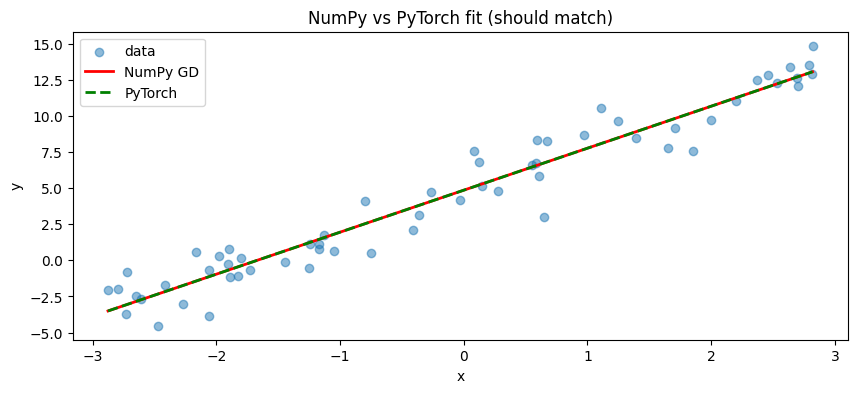

In [ ]:
# Quick sanity-check plot: pytorch fit vs numpy fit, should overlap
plt.scatter(x, y, alpha=0.5, label="data")
plt.plot(x_line, X_line @ theta_final, 'r-', lw=2, label="NumPy GD")
plt.plot(x_line, (torch.tensor(X_line, dtype=torch.float32) @ theta_t).detach().numpy(),
         'g--', lw=2, label="PyTorch")
plt.legend(); plt.xlabel("x"); plt.ylabel("y")
plt.title("NumPy vs PyTorch fit (should match)")
plt.show()

# Part 2: Polynomial Regression — Degree Sweep
### Underfitting → good fit → overfitting, controlled by a slider

We reuse the matrix-form approach from Part 1. The only change: instead of $X = [1, x]$,
we build $X = [1, x, x^2, x^3, \dots, x^d]$ — the same linear regression machinery, applied to
*engineered features* of $x$.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

np.random.seed(0)
plt.rcParams['figure.figsize'] = (7, 4.5)

## 1. Generate noisy cubic data

$$y = 5x^3 + 2x^2 - x + 4 + \text{noise}$$


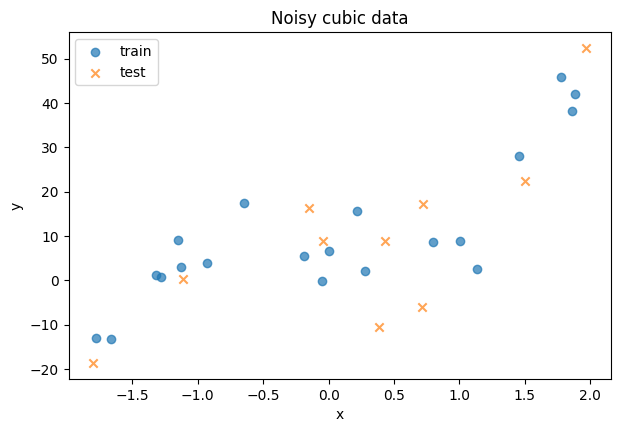

In [ ]:
n_samples = 30
x = np.random.uniform(-2, 2, n_samples)
noise = np.random.normal(0, 6, n_samples)
y = 5 * x**3 + 2 * x**2 - x + 4 + noise

# hold out a test set to show over/underfitting honestly
idx = np.random.permutation(n_samples)
train_idx, test_idx = idx[:20], idx[20:]
x_train, y_train = x[train_idx], y[train_idx]
x_test, y_test = x[test_idx], y[test_idx]

plt.scatter(x_train, y_train, alpha=0.7, label="train")
plt.scatter(x_test, y_test, alpha=0.7, label="test", marker='x')
plt.legend(); plt.xlabel("x"); plt.ylabel("y"); plt.title("Noisy cubic data")
plt.show()

## 2. Build a polynomial design matrix and solve via the normal equation

For high degrees, gradient descent gets numerically painful without feature scaling — since we
already showed GD vs. closed-form is the same answer in Part 1, here we just use the normal
equation directly so we can focus on the degree, not on tuning a learning rate.

$$X_d = [1,\ x,\ x^2,\ \dots,\ x^d] \qquad \theta = (X_d^TX_d)^{-1}X_d^Ty$$


In [ ]:
def poly_features(x, degree):
    """Build [1, x, x^2, ..., x^degree] design matrix."""
    return np.column_stack([x ** p for p in range(degree + 1)])

def fit_poly(x_train, y_train, degree):
    X = poly_features(x_train, degree)
    theta = np.linalg.pinv(X.T @ X) @ X.T @ y_train.reshape(-1, 1)
    return theta

def mse(x, y, theta, degree):
    X = poly_features(x, degree)
    y_pred = X @ theta
    return np.mean((y_pred.ravel() - y) ** 2)

## 3. Interactive degree slider

Drag the degree up. Watch: the fit improves, then starts wiggling to chase noise — while the
**test** error stops improving (or gets worse) even as **train** error keeps shrinking. That gap
*is* overfitting, visually.


In [ ]:
x_line = np.linspace(x.min() - 0.3, x.max() + 0.3, 200)

def plot_degree(degree):
    theta = fit_poly(x_train, y_train, degree)
    X_line = poly_features(x_line, degree)
    y_line = X_line @ theta

    train_err = mse(x_train, y_train, theta, degree)
    test_err = mse(x_test, y_test, theta, degree)

    plt.figure(figsize=(7, 4.5))
    plt.scatter(x_train, y_train, alpha=0.6, label="train")
    plt.scatter(x_test, y_test, alpha=0.6, label="test", marker='x')
    plt.plot(x_line, y_line, 'r-', lw=2, label=f"degree {degree} fit")
    plt.ylim(y.min() - 20, y.max() + 20)
    plt.title(f"degree={degree} | train MSE={train_err:.1f} | test MSE={test_err:.1f}")
    plt.legend(); plt.xlabel("x"); plt.ylabel("y")
    plt.show()

interact(plot_degree, degree=widgets.IntSlider(min=1, max=20, step=1, value=1));

interactive(children=(IntSlider(value=1, description='degree', max=20, min=1), Output()), _dom_classes=('widge…

## 4. Train vs. test error as degree increases — the classic U-curve

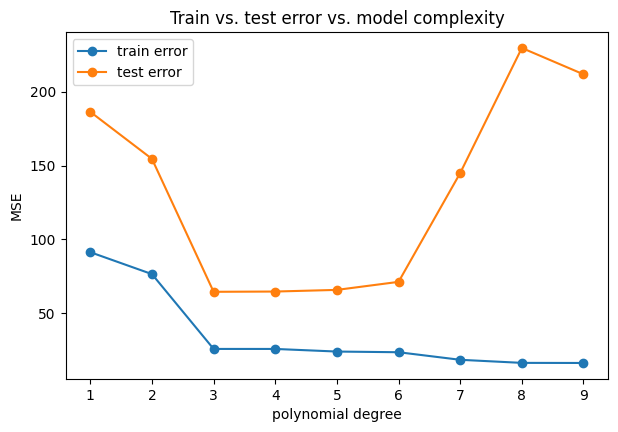

Best degree by test error: 3 (true underlying degree was 3)


In [ ]:
degrees = range(1, 10)
train_errors, test_errors = [], []

for d in degrees:
    theta = fit_poly(x_train, y_train, d)
    train_errors.append(mse(x_train, y_train, theta, d))
    test_errors.append(mse(x_test, y_test, theta, d))

plt.plot(degrees, train_errors, 'o-', label="train error")
plt.plot(degrees, test_errors, 'o-', label="test error")
plt.xlabel("polynomial degree"); plt.ylabel("MSE")
plt.title("Train vs. test error vs. model complexity")
plt.legend(); plt.show()

best_degree = degrees[int(np.argmin(test_errors))]
print(f"Best degree by test error: {best_degree} (true underlying degree was 3)")

In [ ]:
def fit_poly_gd(x_train, y_train, x_test, y_test, degree, lr=0.05, epochs=50):
    """Gradient descent on standardized polynomial features [x, x^2, ..., x^degree].
    Returns per-epoch train and test MSE history."""
    X_raw_train = np.column_stack([x_train ** p for p in range(1, degree + 1)])
    mean, std = X_raw_train.mean(axis=0), X_raw_train.std(axis=0)
    X_train_s = np.column_stack([np.ones(len(x_train)), (X_raw_train - mean) / std])

    X_raw_test = np.column_stack([x_test ** p for p in range(1, degree + 1)])
    X_test_s = np.column_stack([np.ones(len(x_test)), (X_raw_test - mean) / std])

    y_tr, y_te = y_train.reshape(-1, 1), y_test.reshape(-1, 1)
    n = len(x_train)
    theta = np.zeros((degree + 1, 1))

    train_hist, test_hist = [], []
    for _ in range(epochs):
        pred_train = X_train_s @ theta
        train_hist.append(np.mean((pred_train - y_tr) ** 2))
        test_hist.append(np.mean((X_test_s @ theta - y_te) ** 2))

        grad = (2 / n) * X_train_s.T @ (pred_train - y_tr)
        theta = theta - lr * grad

    return train_hist, test_hist


def plot_degree_epochs(degree):
    train_hist, test_hist = fit_poly_gd(x_train, y_train, x_test, y_test, degree,
                                         lr=0.05, epochs=50)
    best_epoch = int(np.argmin(test_hist))

    plt.figure(figsize=(7, 4.5))
    plt.plot(train_hist, label="train error")
    plt.plot(test_hist, label="test error")
    plt.axvline(best_epoch, color='gray', ls='--', alpha=0.6,
                label=f"best test epoch ({best_epoch})")
    plt.xlabel("epoch"); plt.ylabel("MSE")
    plt.title(f"degree={degree} | train vs. test error over training")
    plt.legend()
    plt.show()

interact(plot_degree_epochs, degree=widgets.IntSlider(min=1, max=14, step=1, value=1));

interactive(children=(IntSlider(value=1, description='degree', max=14, min=1), Output()), _dom_classes=('widge…

**Takeaway:** test error is minimized near the *true* degree (3), then rises again as the model
starts fitting noise instead of signal — even though train error keeps dropping. This is the
bias–variance tradeoff, shown without deriving it.


# Part 3: "Feature Importance" — Intuition via Regularization
### Still 1 variable — but many *engineered* features ($x, x^2, \dots, x^d$)

We deliberately overfit with a high-degree polynomial (like the right side of Part 2's U-curve),
then watch **Lasso regression** shrink the coefficients of the *irrelevant* terms to exactly zero
as we increase the regularization strength $\lambda$. Whatever survives with a nonzero
coefficient is, informally, an "important feature."


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

np.random.seed(0)
plt.rcParams['figure.figsize'] = (8, 5)

## 1. Reuse the noisy cubic data, but fit a high-degree (degree 10) polynomial

True relationship only needs terms up to $x^3$. Degrees 4–10 are "noise-fitting" features —
we want to see Lasso identify that.


In [ ]:
n_samples = 30
x = np.random.uniform(-2, 2, n_samples)
noise = np.random.normal(0, 6, n_samples)
y = 5 * x**3 + 2 * x**2 - x + 4 + noise

degree = 10
X_poly = np.column_stack([x ** p for p in range(1, degree + 1)])  # exclude bias col; Lasso has its own intercept

# standardize features -- important for regularization to treat terms fairly
# (x^10 has a wildly different scale than x^1, which would distort penalty strength)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

feature_names = [f"x^{p}" for p in range(1, degree + 1)]

## 2. Fit Lasso across a range of $\lambda$ (called `alpha` in sklearn) and track each coefficient

$$\min_\theta \ \lVert X\theta - y \rVert^2 + \lambda \lVert \theta \rVert_1$$

The $\lVert\theta\rVert_1$ penalty is what makes Lasso special: it pushes weak coefficients all the
way to **zero**, not just small — unlike Ridge ($\lVert\theta\rVert_2^2$), which only shrinks them.


In [ ]:
alphas = np.logspace(-2, 2.5, 60)
coefs = []

for a in alphas:
    model = Lasso(alpha=a, max_iter=20000)
    model.fit(X_scaled, y)
    coefs.append(model.coef_)

coefs = np.array(coefs)   # shape (n_alphas, degree)

## 3. The Lasso path

Each line is one polynomial term's coefficient as $\lambda$ (x-axis, log scale) increases.
Notice which lines hit zero *first* (unimportant / noise-fitting terms) and which survive
longest (the true underlying terms: $x, x^2, x^3$).


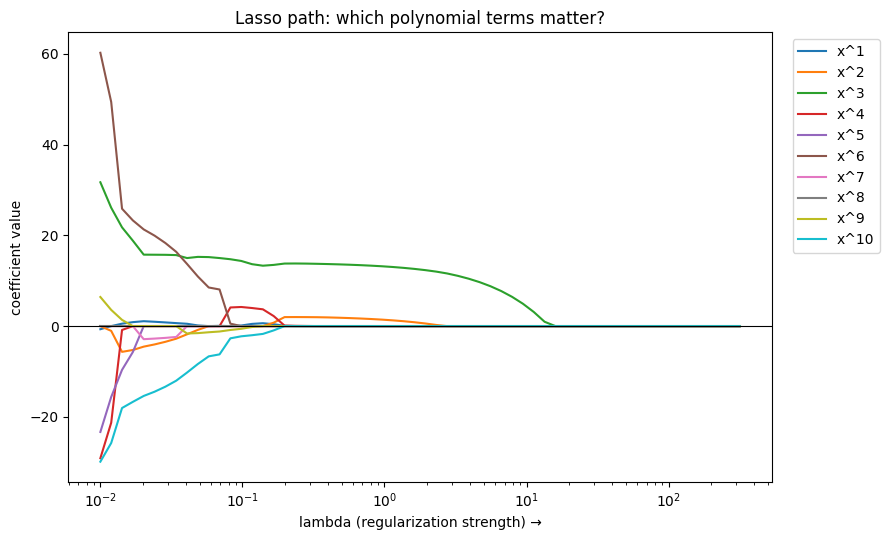

In [ ]:
plt.figure(figsize=(9, 5.5))
for i in range(degree):
    plt.plot(alphas, coefs[:, i], label=feature_names[i])

plt.xscale('log')
plt.xlabel("lambda (regularization strength) →")
plt.ylabel("coefficient value")
plt.title("Lasso path: which polynomial terms matter?")
plt.axhline(0, color='k', lw=0.8)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 4. Read off "important" features at a chosen $\lambda$


In [ ]:
chosen_alpha = 1
model = Lasso(alpha=chosen_alpha, max_iter=20000)
model.fit(X_scaled, y)

importance = sorted(zip(feature_names, model.coef_), key=lambda t: -abs(t[1]))
print(f"At lambda = {chosen_alpha}:")
for name, coef in importance:
    marker = "  <-- zeroed out" if coef == 0 else ""
    print(f"  {name:6s}: {coef:8.3f}{marker}")

At lambda = 1:
  x^3   :   13.149
  x^2   :    1.397
  x^1   :    0.000  <-- zeroed out
  x^4   :    0.000  <-- zeroed out
  x^5   :    0.000  <-- zeroed out
  x^6   :    0.000  <-- zeroed out
  x^7   :    0.000  <-- zeroed out
  x^8   :    0.000  <-- zeroed out
  x^9   :    0.000  <-- zeroed out
  x^10  :    0.000  <-- zeroed out


**Takeaway for students:** "feature importance" doesn't require a separate algorithm here —
it falls out of watching *which coefficients survive regularization*. This is the same idea
we'll reach for with real, multivariate data in Part 4, just with actual named features
(`MedInc`, `HouseAge`, ...) instead of $x^2, x^3, \dots$


# Part 4: Real-World Data — California Housing
### Applying the same intuition: eyeball features, eyeball degree, confirm with Lasso

No grid search here on purpose — the goal is for students to practice the *intuitive* workflow:
1. look at each feature vs. target,
2. guess whether it looks linear / curved / irrelevant,
3. guess a reasonable polynomial degree from the shape,
4. confirm with a correlation heatmap and Lasso coefficients,
5. sanity check with train/test error.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error, root_mean_squared_error

plt.rcParams['figure.figsize'] = (7, 4.5)

data = fetch_california_housing(as_frame=True)
df = data.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 1. What are we predicting?

`MedHouseVal` — median house value (in $100,000s) for a block group, from features like
median income, house age, average rooms, population, location, etc.


In [ ]:
df.describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
MedInc,3.870671,1.899822,0.499900,15.000100
HouseAge,28.639486,12.585558,1.000000,52.000000
AveRooms,5.429000,2.474173,0.846154,141.909091
AveBedrms,1.096675,0.473911,0.333333,34.066667
Population,1425.476744,1132.462122,3.000000,35682.000000
AveOccup,3.070655,10.386050,0.692308,1243.333333
Latitude,35.631861,2.135952,32.540000,41.950000
Longitude,-119.569704,2.003532,-124.350000,-114.310000
MedHouseVal,2.068558,1.153956,0.149990,5.000010


## 2. Eyeball each feature vs. target

Look at the *shape* of each scatter: roughly a straight line? a curve? a shapeless blob (no
relationship)? That's your first guess at both **whether to include it** and **what degree** to
use for it.


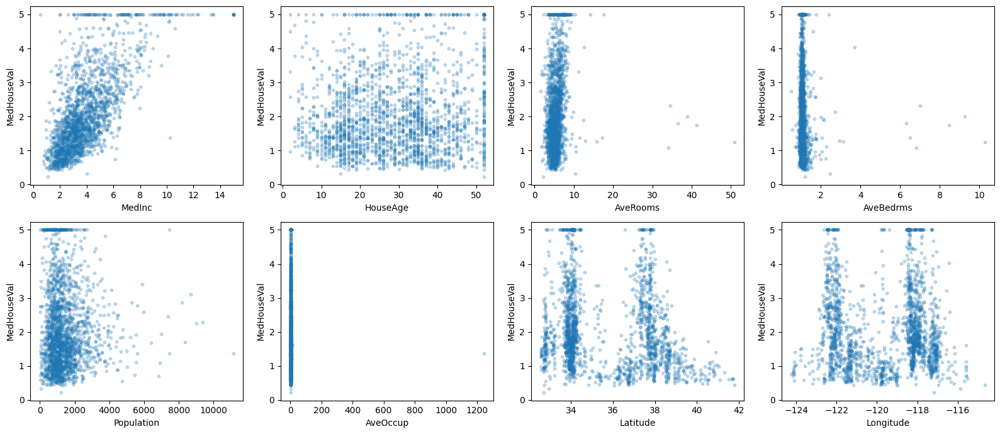

In [ ]:
features = [c for c in df.columns if c != 'MedHouseVal']
target = 'MedHouseVal'

# subsample points for a readable scatter (20k rows is too dense to eyeball)
sample = df.sample(2000, random_state=0)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, feat in zip(axes.ravel(), features):
    ax.scatter(sample[feat], sample[target], alpha=0.25, s=10)
    ax.set_xlabel(feat); ax.set_ylabel(target)
plt.tight_layout()
plt.show()

## 3. Correlation heatmap — a quick numeric complement to eyeballing

Correlation only captures *linear* relationship strength, so it agrees with what "looks straight"
above, and disagrees where the true relationship is curved (a reminder that correlation isn't the
whole story — just a fast first pass).


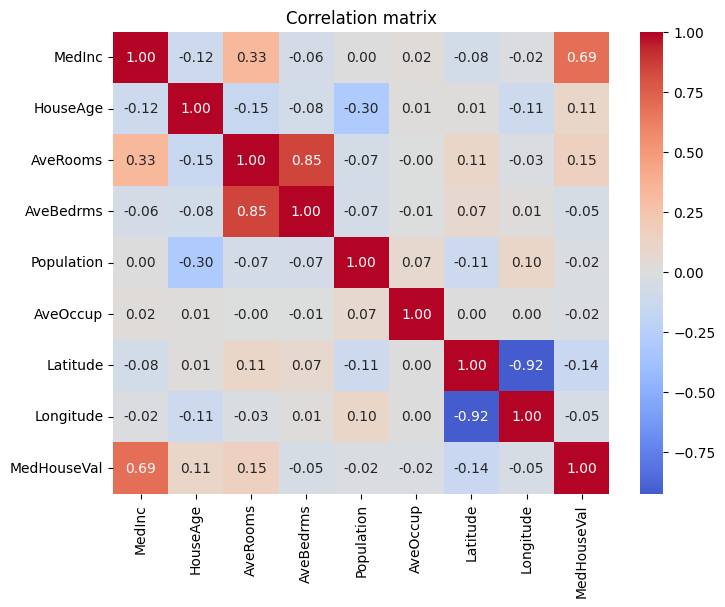

Correlation with target, sorted:
MedInc        0.688075
AveRooms      0.151948
Latitude     -0.144160
HouseAge      0.105623
AveBedrms    -0.046701
Longitude    -0.045967
Population   -0.024650
AveOccup     -0.023737
Name: MedHouseVal, dtype: float64


In [ ]:
corr = df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.show()

print("Correlation with target, sorted:")
print(corr[target].drop(target).sort_values(key=abs, ascending=False))

## 4. Pick per-feature degrees by eye, then fit

Based on the scatter shapes, here's a reasonable starting guess (edit these live in class and
discuss):
- `MedInc`: looks linear → degree 1
- `HouseAge`: mild curve → degree 2
- `AveRooms`, `AveOccup`: noisy / outlier-heavy → degree 1, maybe worth clipping outliers first
- `Latitude`, `Longitude`: not usefully modeled as 1D polynomials at all (they interact with each
  other — that's a multivariate story) → leave as degree 1 for now, flag as a limitation


In [ ]:
degree_choices = {
    'MedInc': 1,
    'HouseAge': 2,
    'AveRooms': 1,
    'AveBedrms': 1,
    'Population': 1,
    'AveOccup': 1,
    'Latitude': 1,
    'Longitude': 1,
}

def build_design_matrix(df, degree_choices):
    cols = []
    names = []
    for feat, deg in degree_choices.items():
        x = df[feat].values
        for p in range(1, deg + 1):
            cols.append(x ** p)
            names.append(f"{feat}^{p}" if p > 1 else feat)
    return np.column_stack(cols), names

X, feat_names = build_design_matrix(df, degree_choices)
y = df[target].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_s, y_train)

train_pred = model.predict(X_train_s)
test_pred = model.predict(X_test_s)
print(f"Train RMSE: {root_mean_squared_error(y_train, train_pred):.3f}")
print(f"Test RMSE:  {root_mean_squared_error(y_test, test_pred):.3f}")

Train RMSE: 0.722
Test RMSE:  0.726


## 5. Confirm feature importance with Lasso

Same trick as Part 3, now with real named features. Which of our eyeballed choices actually
survive regularization?


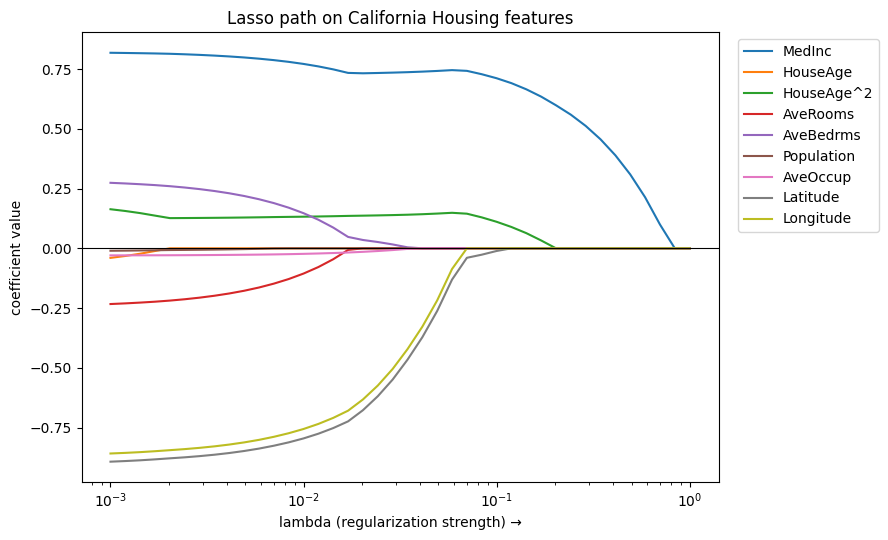

In [ ]:
alphas = np.logspace(-3, 0, 40)
coefs = []
for a in alphas:
    lasso = Lasso(alpha=a, max_iter=20000)
    lasso.fit(X_train_s, y_train)
    coefs.append(lasso.coef_)
coefs = np.array(coefs)

plt.figure(figsize=(9, 5.5))
for i, name in enumerate(feat_names):
    plt.plot(alphas, coefs[:, i], label=name)
plt.xscale('log')
plt.xlabel("lambda (regularization strength) →")
plt.ylabel("coefficient value")
plt.title("Lasso path on California Housing features")
plt.axhline(0, color='k', lw=0.8)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
chosen_alpha = 0.05
lasso = Lasso(alpha=chosen_alpha, max_iter=20000)
lasso.fit(X_train_s, y_train)

importance = sorted(zip(feat_names, lasso.coef_), key=lambda t: -abs(t[1]))
print(f"Feature importance at lambda={chosen_alpha}:")
for name, coef in importance:
    print(f"  {name:14s}: {coef:8.3f}")

Feature importance at lambda=0.05:
  MedInc        :    0.742
  Latitude      :   -0.252
  Longitude     :   -0.207
  HouseAge^2    :    0.146
  HouseAge      :    0.000
  AveRooms      :   -0.000
  AveBedrms     :    0.000
  Population    :   -0.000
  AveOccup      :   -0.000


**Wrap-up discussion:**
- `MedInc` should dominate — matches both the correlation heatmap and the linear-looking scatter.
- Terms that stay near zero even at low $\lambda$ are candidates to drop entirely.
- `Latitude`/`Longitude` being weak individually — despite obviously affecting price in
  reality — is a good hook for *why* we eventually need multivariate / interaction terms or
  models beyond simple polynomial regression (e.g. geographic clustering, decision trees).
